In [5]:
import kagglehub
path = kagglehub.dataset_download("carrie1/ecommerce-data")

Using Colab cache for faster access to the 'ecommerce-data' dataset.


In [6]:
import os
print(os.listdir(path))

['data.csv']


In [7]:
import pandas as pd
df = pd.read_csv(path + '/data.csv', encoding='latin1')
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [11]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')
Categorical Columns: Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')


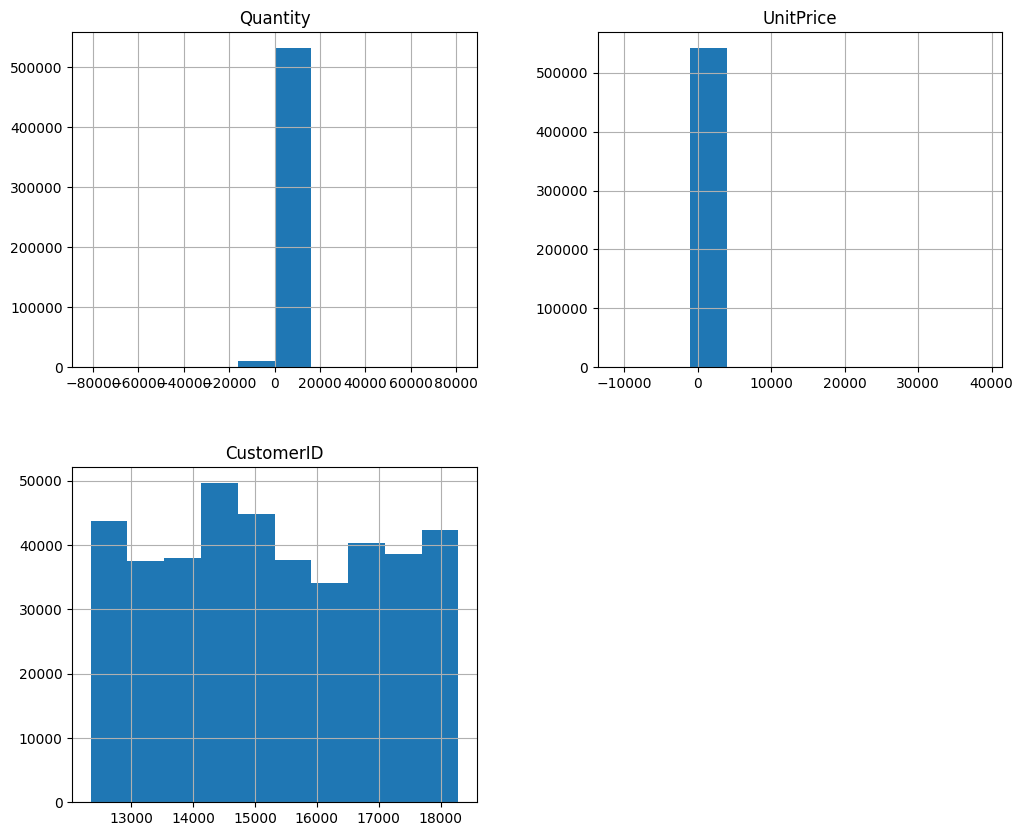

In [12]:
df[num_cols].hist(figsize=(12,10))
plt.show()

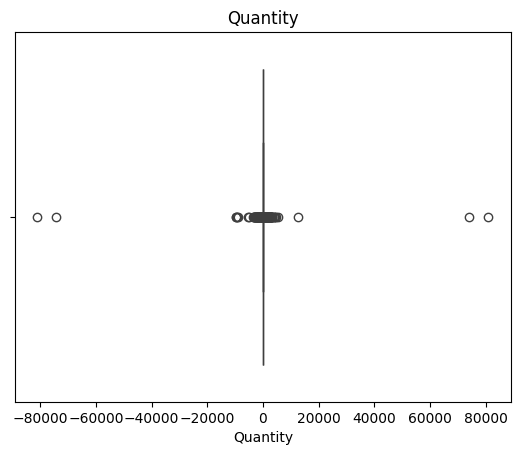

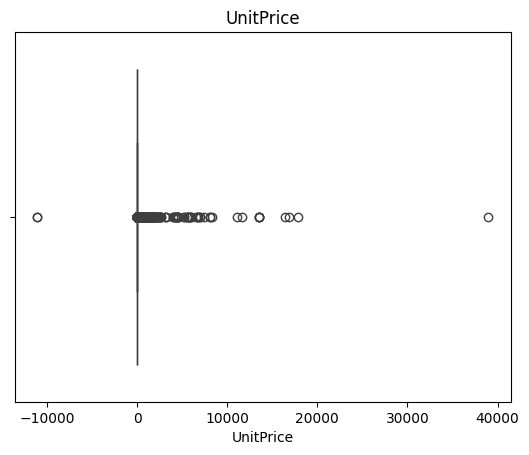

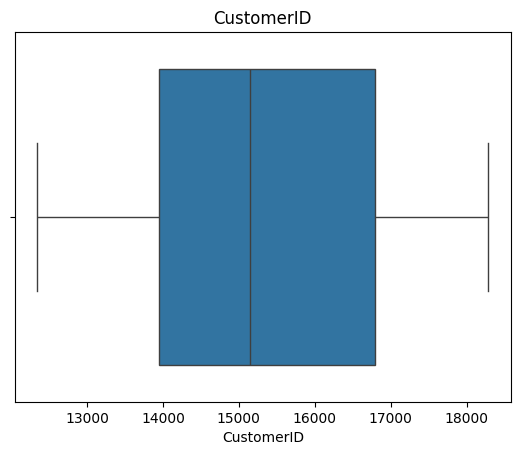

In [13]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts().head())


 InvoiceNo
InvoiceNo
573585    1114
581219     749
581492     731
580729     721
558475     705
Name: count, dtype: int64

 StockCode
StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
Name: count, dtype: int64

 Description
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
Name: count, dtype: int64

 InvoiceDate
InvoiceDate
10/31/2011 14:41    1114
12/8/2011 9:28       749
12/9/2011 10:03      731
12/5/2011 17:24      721
6/29/2011 15:58      705
Name: count, dtype: int64

 Country
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64


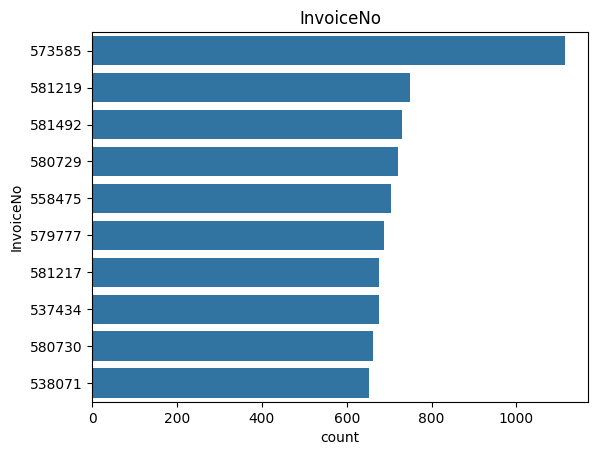

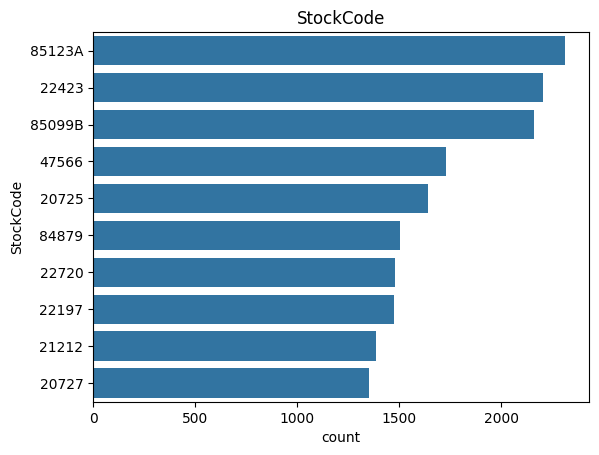

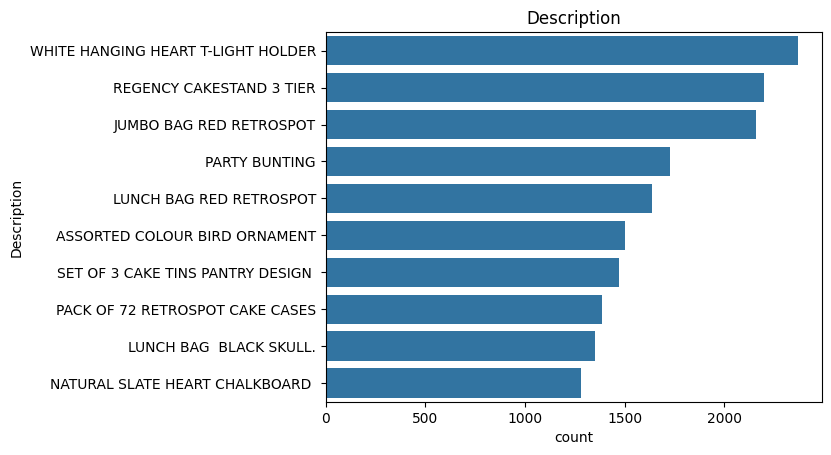

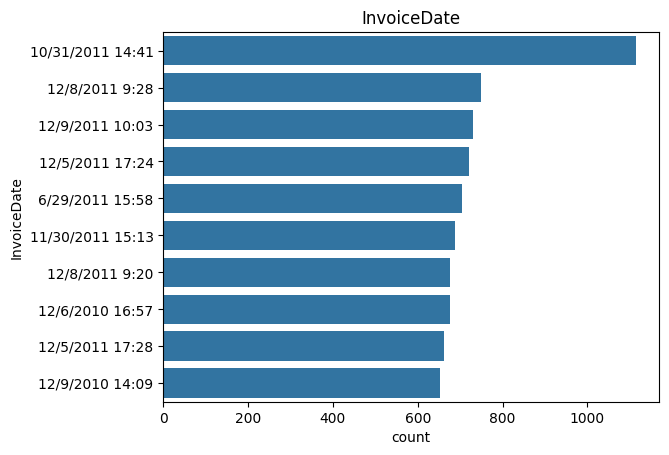

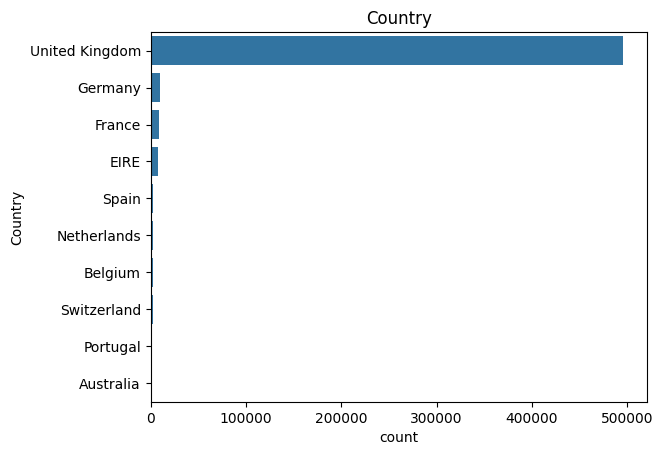

In [15]:
for col in cat_cols:
    plt.figure()
    sns.countplot(y=col, data=df, order=df[col].value_counts().index[:10])
    plt.title(col)
    plt.show()

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
sns.pairplot(df[num_cols])
plt.show()

In [ ]:
sns.pairplot(df[num_cols[:4]])

In [ ]:
sns.boxplot(x='category_column', y='target_column', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.groupby('category_column')['target_column'].mean().sort_values(ascending=False)

In [ ]:
df.groupby('category_column')['target_column'].sum().sort_values(ascending=False)

In [ ]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]

    print(f"{col}: {len(outliers)} outliers")

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df.groupby('date')['target_column'].sum().plot(figsize=(10,5))
plt.show()